# ESP32 CSI, Preprocessing Pipeline

**Project:** WIFIAD — WiFi Channel State Information for Indoor Presence Detection  
**Hardware:** ESP32 running custom CSI logger  
**Task:** Binary classification `empty` vs `occupied`  
**Sessions:** `01_session.csv` (~15 min),`02_session.csv` (~18 min)

---

### What is CSI?

802.11 OFDM Wi-Fi uses 64 subcarriers per packet. For each TX => RX packet the receiver
estimates a complex channel coefficient per subcarrier amplitude and phase. The amplitude
vector `[amp_0 ... amp_63]` is what we record. When a person enters the room, their body
reflects and absorbs RF energy, perturbing these amplitudes in characteristic ways.

### Pipeline overview

1. Load CSVs, verify labels and counts  
2. Drop guard + pilot subcarriers (indices 0, 1, 27–36, 63) these carry no data  
3. Visualise the raw signal to understand its structure  
4. Append scalar summary features (mean, std, max, energy) per frame
5. Encode labels and build feature matrix  
6. Session-based train/test split => scale => save 

## Step 1 — Load Data

Each CSV row is one packet. We tag each row with its session so we can later split by session
rather than by row index (which would leak temporal information across the boundary)

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, pickle

RAW_DIR   = "../data/feasibility-study/raw"
PROC_DIR  = "../data/feasibility-study/processed"
os.makedirs(PROC_DIR, exist_ok=True)

SAVE_DIR  = 'feasibility-study-outputs'
os.makedirs(SAVE_DIR, exist_ok=True)

AMP_COLS = [f"amp_{i}" for i in range(64)]

dfs = []
for session, filename in [("session1", "01_session.csv"), ("session2", "02_session.csv")]:
    tmp = pd.read_csv(f"{RAW_DIR}/{filename}", on_bad_lines="skip", low_memory=False)
    tmp["session"] = session
    dfs.append(tmp)

df = pd.concat(dfs, ignore_index=True).dropna().reset_index(drop=True)

print(f"Total rows: {len(df):,}")
print(f"\nUnique labels: {df['label'].unique()}")
print(f"\nRows per session x label:")
print(df.groupby(["session", "label"]).size().unstack(fill_value=0))

Total rows: 142,628

Unique labels: <StringArray>
['exist', 'empty']
Length: 2, dtype: str

Rows per session x label:
label     empty  exist
session               
session1  23635  47881
session2  26706  44406


**Observations:**  
142 628 rows across two sessions. Labels are clean (`empty` / `exist`), no nulls or unexpected values.  
Session 1 has ~2× more `exist` than `empty` we will handle this with class-weight balancing in classifiers.

**Decision rename `exist` => `occupied`:** The label `exist` is ambiguous out of context,
`occupied` makes the binary task self explanatory in code and plots.

In [11]:
df["label"] = df["label"].replace({"exist": "occupied"})
print(df["label"].value_counts())

label
occupied    92287
empty       50341
Name: count, dtype: int64


## Step 2 - Drop Guard and Pilot Subcarriers

Of the 64 OFDM subcarriers, several are reserved and carry no payload information:

| Group | Indices | Purpose |
|---|---|---|
| DC null | 0 | Centre carrier, always zero |
| Guard (low) | 1 | Spectral guard |
| Pilots | 7, 21, 43, 57 | Channel tracking fixed amplitude |
| Guard (high) | 27–36 | Spectral guard |
| Upper guard | 63 | Spectral guard |

We drop these and keep **51** active data subcarriers: `amp_2–26` and `amp_37–62`.
Including guards/pilots would add zero variance or fixed amplitude features that
can only introduce noise into distance based or linear models.

In [12]:
DROP_IDX = [0, 1] + list(range(27, 37)) + [63]
DROP_COLS = [f"amp_{i}" for i in DROP_IDX]
ACTIVE_COLS = [c for c in AMP_COLS if c not in DROP_COLS]

print(f"Active subcarriers: {len(ACTIVE_COLS)}")
print(f"Dropped:  {DROP_COLS}")

Active subcarriers: 51
Dropped:  ['amp_0', 'amp_1', 'amp_27', 'amp_28', 'amp_29', 'amp_30', 'amp_31', 'amp_32', 'amp_33', 'amp_34', 'amp_35', 'amp_36', 'amp_63']


## Step 3 — Signal Visualisation

Before modelling we inspect three views of the data:
1. **Mean CSI profile** — average amplitude per subcarrier per label. Reveals which
   subcarriers carry the most discriminative information.
2. **RSSI distribution** — overall received signal strength. Tells us about multipath richness.
3. **Temporal signal** — amplitude of one subcarrier over time. Exposes non stationarity
   and drift between sessions a critical factor for cross session generalisation.

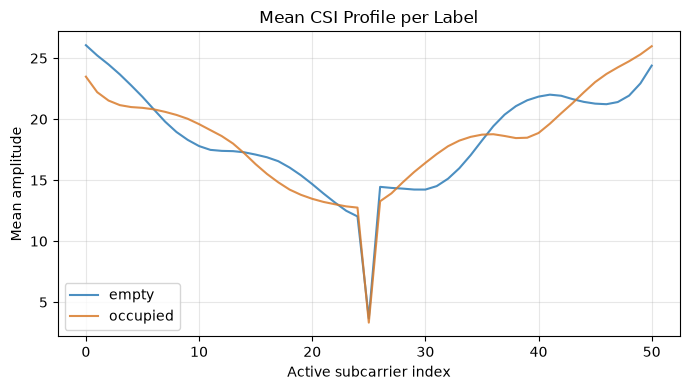

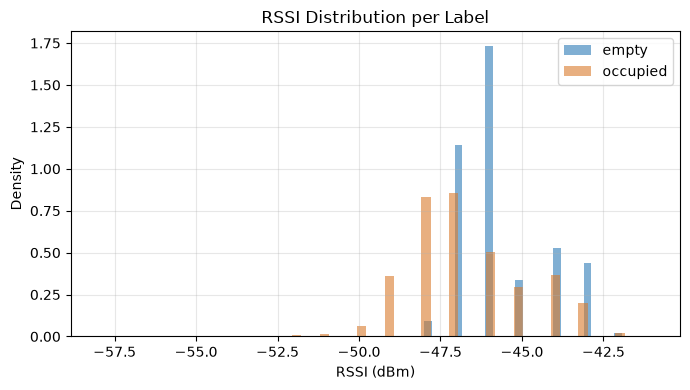

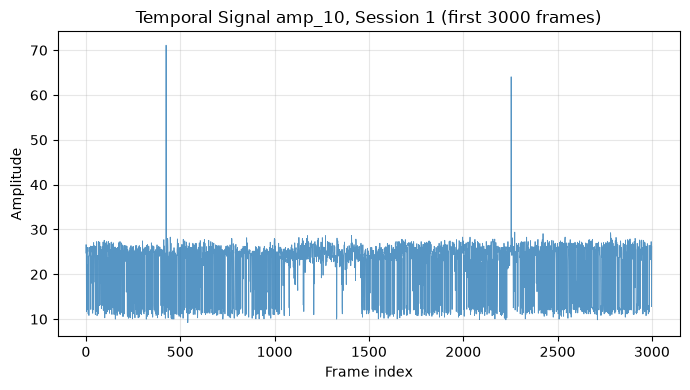

In [13]:
# --- Plot 1: Mean CSI amplitude profile per label -----------------------
fig, ax = plt.subplots(figsize=(7, 4))
for (label, grp), color in zip(df.groupby("label"), ['#2C7BB6', '#D97B2B']):
    ax.plot(grp[ACTIVE_COLS].mean().values, label=label, alpha=0.85, color=color)
ax.set_title("Mean CSI Profile per Label")
ax.set_xlabel("Active subcarrier index")
ax.set_ylabel("Mean amplitude")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/00_csi_profile.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Plot 2: RSSI distribution per label ----------------------------------
fig, ax = plt.subplots(figsize=(7, 4))
for (label, grp), color in zip(df.groupby("label"), ['#2C7BB6', '#D97B2B']):
    ax.hist(grp["rssi"], bins=60, alpha=0.6, label=label, density=True, color=color)
ax.set_title("RSSI Distribution per Label")
ax.set_xlabel("RSSI (dBm)")
ax.set_ylabel("Density")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/00_rssi_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Plot 3: Temporal signal — subcarrier amp_10, session 1 --------------
fig, ax = plt.subplots(figsize=(7, 4))
s1 = df[df["session"] == "session1"].reset_index(drop=True)
ax.plot(s1["amp_10"].values[:3000], linewidth=0.6, alpha=0.8, color='#2C7BB6')
ax.set_title("Temporal Signal amp_10, Session 1 (first 3000 frames)")
ax.set_xlabel("Frame index")
ax.set_ylabel("Amplitude")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/00_temporal_signal.png', dpi=150, bbox_inches='tight')
plt.show()

**Observations:**  
- The mean CSI profiles for `empty` and `occupied` overlap substantially in the mid-band subcarriers.
  Discrimination is not trivially visible in the frequency domain the differences are in
  the temporal variance structure, not the mean.
- RSSI distributions largely overlap, confirming that RSSI alone is not a reliable feature.
- The temporal signal shows clear non-stationarity: the amplitude drifts over time even within
  a session. This is the first indication that cross-session generalisation will be difficult.

## Step 4 — Scalar Summary Features

The 54-dimensional amplitude vector per frame is our primary feature. We augment it with
four scalar statistics computed across the active subcarriers:

| Feature | Formula | Intuition |
|---|---|---|
| `csi_mean` | mean(amp) | Average signal level |
| `csi_std` | std(amp) | Frequency diversity (multipath richness) |
| `csi_max` | max(amp) | Peak subcarrier response |
| `csi_energy` | sum(amp^2) | Total received energy |

Human presence tends to increase multipath scattering, raising `csi_std` and `csi_energy`.
These scalars give linear models a chance without requiring them to model temporal structure.

In [14]:
amp_vals = df[ACTIVE_COLS].values.astype(np.float32)

df["csi_mean"]   = amp_vals.mean(axis=1)
df["csi_std"]    = amp_vals.std(axis=1)
df["csi_max"]    = amp_vals.max(axis=1)
df["csi_energy"] = (amp_vals ** 2).sum(axis=1)

FEATURE_COLS = ACTIVE_COLS + ["csi_mean", "csi_std", "csi_max", "csi_energy"]
print(f"Total features per frame: {len(FEATURE_COLS)}")
df[FEATURE_COLS].describe().round(2)

Total features per frame: 55


,amp_2,amp_3,amp_4,amp_5,amp_6,amp_7,amp_8,amp_9,amp_10,amp_11,...,amp_57,amp_58,amp_59,amp_60,amp_61,amp_62,csi_mean,csi_std,csi_max,csi_energy
count,142628.00,142628.00,142628.00,142628.00,142628.00,142628.00,142628.00,142628.00,142628.00,142628.00,...,142628.00,142628.00,142628.00,142628.00,142628.00,142628.00,142628.00,142628.00,142628.00,142628.00
mean,24.39,23.27,22.57,22.04,21.62,21.24,20.80,20.31,19.85,19.42,...,22.41,22.83,23.24,23.75,24.46,25.42,18.37,4.74,27.70,19743.61
std,7.72,7.67,7.44,6.98,6.43,6.00,5.77,5.78,5.91,5.98,...,6.56,7.07,7.42,7.54,7.47,7.37,5.05,1.35,7.70,9950.42
min,2.00,3.61,5.00,3.00,1.00,3.61,2.83,3.16,2.24,4.12,...,1.41,2.00,4.12,2.83,3.16,3.61,2.54,1.70,9.22,474.99
25%,18.87,17.12,16.97,17.26,18.03,17.49,17.00,16.00,15.00,14.14,...,16.55,16.16,16.28,16.55,17.46,19.10,14.79,3.80,22.47,11910.87
50%,25.08,23.34,22.80,22.67,23.20,23.71,23.34,22.20,21.10,20.22,...,23.77,23.32,23.41,24.19,25.94,28.02,20.75,5.19,31.06,23452.03
75%,31.11,30.23,29.21,28.07,26.63,25.32,24.70,24.41,24.41,24.33,...,27.80,29.21,30.15,30.59,30.61,30.81,21.69,5.64,32.65,25550.95
max,109.04,106.08,103.95,98.23,95.77,90.82,81.15,83.49,87.09,90.71,...,91.24,87.82,86.68,94.41,107.56,112.93,72.60,19.84,112.93,282104.53


**Observations:**
- Subcarrier amplitudes follow a U-shaped profile across the band: edge subcarriers
  (amp_2, amp_62) average ~24–25, center subcarriers dip to ~18–19. Consistent with
  typical 802.11 channel frequency response.
- High std across all subcarriers (~6–8) relative to the mean (~18–25) indicates
  significant frame to frame variability the channel is not static even in an empty room.
- `csi_std` mean=4.74, std=1.35: narrow distribution, suggesting within frame frequency
  diversity is fairly stable. A persistent occupant should push this upward.
- `csi_energy` has the highest coefficient of variation (std/mean ≈ 0.50), making it
  the most discriminative scalar candidate for presence detection.

## Step 5 — Label Encoding

`empty => 0`, `occupied => 1`. Binary integer labels are required by PyTorch CrossEntropyLoss
and scikit-learn classifiers. We verify the mapping and build the full feature matrix X.

In [15]:
LABEL_MAP = {"empty": 0, "occupied": 1}
df["label_enc"] = df["label"].map(LABEL_MAP)

X = df[FEATURE_COLS].values.astype(np.float32)
y = df["label_enc"].values.astype(np.int64)
sessions = df["session"].values

print(f"Feature matrix X: {X.shape}")
print(f"Label vector  y: {y.shape}")
print(f"Label counts - 0 (empty): {(y==0).sum():,} | 1 (occupied): {(y==1).sum():,}")

Feature matrix X: (142628, 55)
Label vector  y: (142628,)
Label counts - 0 (empty): 50,341 | 1 (occupied): 92,287


## Step 6 — Session-Based Split, Scaling, Save

**Split strategy:** session 1 => train, session 2 => test.

This is the only honest split for time-series sensor data. A random row level split
would allow the model to learn the calibration of the test session during training
temporal autocorrelation between adjacent frames would guarantee near 100 % test accuracy
with zero generalisation. Cross session evaluation simulates the real deployment scenario:
the sensor is recalibrated (or moved) between sessions.

**Scaling:** StandardScaler fit on train only, applied to both splits. Fitting on the
full dataset would leak test statistics into the scaling parameters a common but
subtle form of data leakage.

In [16]:
from sklearn.preprocessing import StandardScaler

train_mask = sessions == "session1"
test_mask  = sessions == "session2"

X_train, y_train = X[train_mask], y[train_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"Train: {X_train.shape} | label dist: empty={(y_train==0).sum():,}  occupied={(y_train==1).sum():,}")
print(f"Test:  {X_test.shape}  | label dist: empty={(y_test==0).sum():,}  occupied={(y_test==1).sum():,}")

# Save
np.save(f"{SAVE_DIR}/X_train.npy", X_train)
np.save(f"{SAVE_DIR}/y_train.npy", y_train)
np.save(f"{SAVE_DIR}/X_test.npy",  X_test)
np.save(f"{SAVE_DIR}/y_test.npy",  y_test)

with open(f"{SAVE_DIR}/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("\nSaved to:", SAVE_DIR)

Train: (71516, 55) | label dist: empty=23,635  occupied=47,881
Test:  (71112, 55)  | label dist: empty=26,706  occupied=44,406

Saved to: feasibility-study-outputs


## Summary

| Item | Value |
|---|---|
| Total frames | 142 628 |
| Active subcarriers | 51 |
| Scalar features appended | 4 |
| Features per frame | 55 |
| Train (session 1) | 71 516 frames |
| Test (session 2) | 71 112 frames |
| Split criterion | Session boundary (no row-level shuffle) |
| Scaler | StandardScaler fit on train only |

All downstream notebooks load `X_train.npy`, `y_train.npy`, `X_test.npy`, `y_test.npy`
from `../data/feasibility-study/processed/`. The scaler is saved for inference use.